In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("/content/Salary Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,373.0,37.431635,7.069073,23.0,31.0,36.0,44.0,53.0
Years of Experience,373.0,10.030831,6.557007,0.0,4.0,9.0,15.0,25.0
Salary,373.0,100577.345845,48240.013482,350.0,55000.0,95000.0,140000.0,250000.0


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [ ]:
df.columns.values

array(['Age', 'Gender', 'Education Level', 'Job Title',
       'Years of Experience', 'Salary'], dtype=object)

In [ ]:
df.duplicated().sum()

np.int64(50)

In [ ]:
df = df.drop_duplicates()
df.shape

(325, 6)

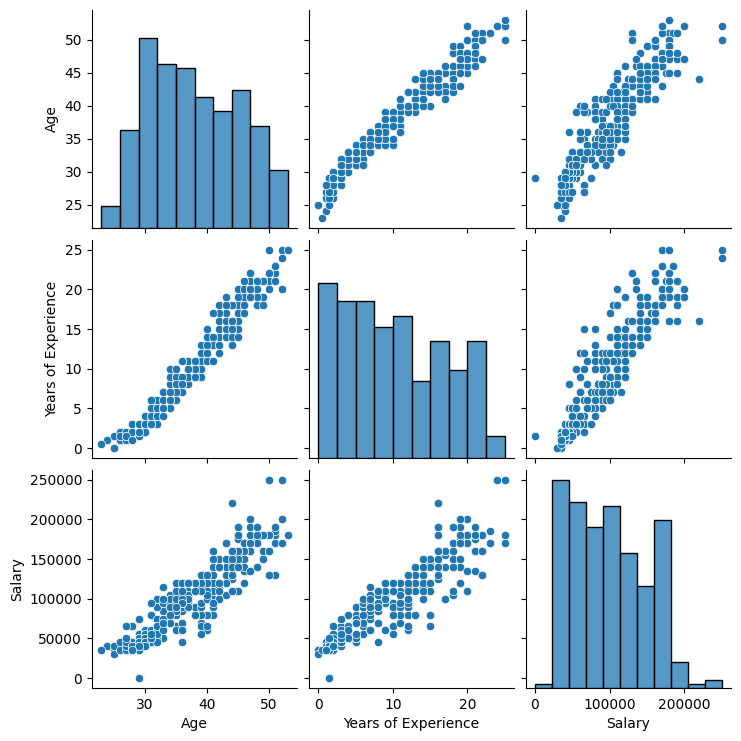

In [ ]:
sns.pairplot(df[['Age', 'Years of Experience', 'Salary']])

<Axes: >

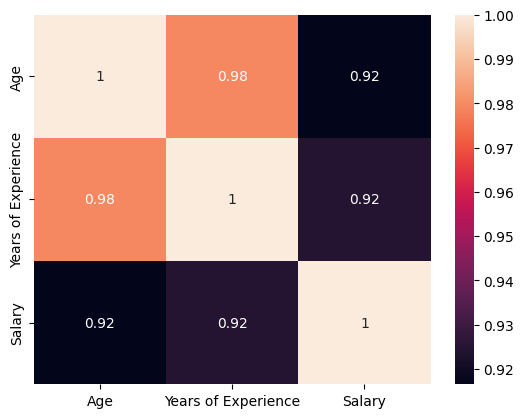

In [ ]:
sns.heatmap(df[['Age', 'Years of Experience', 'Salary']].corr(), annot=True)

<Axes: xlabel='count', ylabel='Gender'>

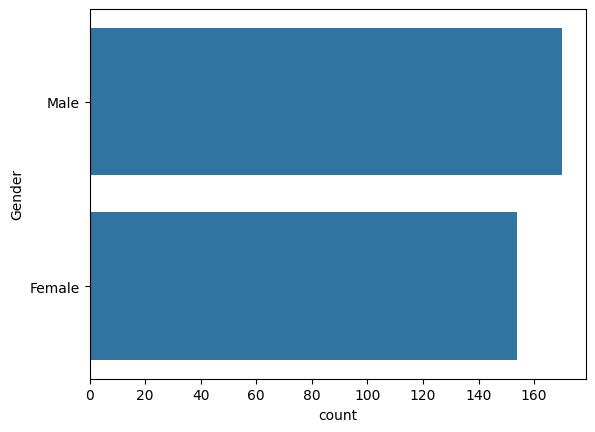

In [ ]:
sns.countplot(df['Gender'])

<Axes: xlabel='count', ylabel='Education Level'>

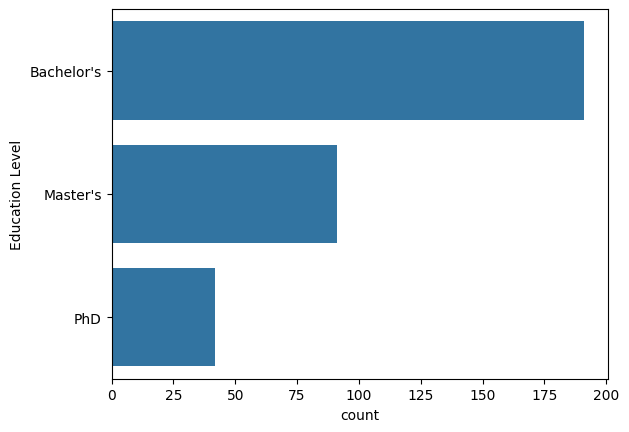

In [ ]:
sns.countplot(df['Education Level'])

In [ ]:
df['Job Title'].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

In [ ]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0
350,44.0,Female,PhD,Senior Data Scientist,16.0,160000.0
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0


In [ ]:
df = df.dropna(subset=['Salary'])
x = df.iloc[:,:5]
y = df.iloc[:,5]
x,y

(      Age  Gender Education Level                            Job Title  \
 0    32.0    Male      Bachelor's                    Software Engineer   
 1    28.0  Female        Master's                         Data Analyst   
 2    45.0    Male             PhD                       Senior Manager   
 3    36.0  Female      Bachelor's                      Sales Associate   
 4    52.0    Male        Master's                             Director   
 ..    ...     ...             ...                                  ...   
 348  28.0  Female      Bachelor's            Junior Operations Manager   
 349  36.0    Male      Bachelor's  Senior Business Development Manager   
 350  44.0  Female             PhD                Senior Data Scientist   
 351  31.0    Male      Bachelor's         Junior Marketing Coordinator   
 371  43.0    Male        Master's               Director of Operations   
 
      Years of Experience  
 0                    5.0  
 1                    3.0  
 2            

In [ ]:
numerical_features = x.select_dtypes(include=np.number).columns
categorical_features = x.select_dtypes(include='object').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat_pipeline', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ],
    remainder='passthrough'
)

# Set the preprocessor to output pandas DataFrames
preprocessor.set_output(transform='pandas')

model = Pipeline(
    (
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    )
)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [ ]:
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Years of Experience'], dtype='object')),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Gender', 'Education Level', 'Job Title'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [ ]:
model.predict(  x_test  )

array([108973.75243841, 113556.07360354,  58819.99394575, 118729.06409861,
       108151.86648807,  98507.49900997,  72863.91831133,  59763.56923619,
       172053.58096925,  41387.86187109,  39380.3411197 , 137782.18475858,
        98645.81368506, 139523.2562804 ,  87281.29411904, 178674.94687193,
       114396.38496569, 108075.48630083,  66210.47258707,  48729.06409861,
        98590.74942351,  51624.9554187 ,  77761.92003063,  55882.53383371,
       165318.35747509,  95857.04876424, 146420.31901004, 136883.76158093,
       169280.48990429,  49393.49080047, 107296.33212017, 173484.86895083,
       105568.25170914])

In [ ]:
import pandas as pd

# Create a DataFrame for a single prediction
new_data = pd.DataFrame({
    'Age': [82.0],
    'Gender': ['Male'],
    'Education Level': ["Bachelor's"],
    'Job Title': ['Software Engineer'],
    'Years of Experience': [0.0]
})

# Make the prediction
prediction = model.predict(new_data)
print(prediction)

[194536.08256403]
